In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import itertools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import sklearn


In [2]:
data = pd.read_csv("Разметка.csv", delimiter=',')
data = data.drop('fid', axis=1)
print(data.shape)
data.drop_duplicates(inplace=True)
categorical_feature = ['target']
label_encoding = LabelEncoder()
for column in categorical_feature:
  data[column] = label_encoding.fit_transform(data[column])
  encoding_dict = {code: label for code, label in enumerate(label_encoding.classes_)}
data

(158194, 16)


,target,Y,X,Z,NDBR,LC08_L1TP_171024_20240814_20240822_02_T1_B10,LC08_L1TP_171024_20240814_20240822_02_T1_B9,LC08_L1TP_171024_20240814_20240822_02_T1_B8,LC08_L1TP_171024_20240814_20240822_02_T1_B7,LC08_L1TP_171024_20240814_20240822_02_T1_B6,LC08_L1TP_171024_20240814_20240822_02_T1_B5,LC08_L1TP_171024_20240814_20240822_02_T1_B4,LC08_L1TP_171024_20240814_20240822_02_T1_B3,LC08_L1TP_171024_20240814_20240822_02_T1_B2,LC08_L1TP_171024_20240814_20240822_02_T1_B1,LC08_L1TP_171024_20240814_20240822_02_T1_B11
0,10,5.719716e+06,555870.805104,108.560387,0.11953,27898.0,5045.0,8819.0,12015.0,15304.0,12036.0,8831.0,8757.0,9533.0,10282.0,25049.0
2,10,5.719666e+06,555970.805104,109.935959,0.10423,28082.0,5043.0,8620.0,11576.0,14879.0,12070.0,8718.0,8666.0,9467.0,10186.0,25232.0
4,10,5.719616e+06,555970.805104,110.191856,0.11538,27892.0,5061.0,8810.0,11827.0,15346.0,12171.0,8881.0,8792.0,9544.0,10255.0,25020.0
6,10,5.719666e+06,556020.805104,109.002014,0.11551,28235.0,5056.0,8813.0,11801.0,15118.0,11987.0,8669.0,8659.0,9440.0,10197.0,25289.0
8,10,5.719616e+06,556020.805104,110.104195,0.13412,28222.0,5054.0,8670.0,11845.0,14946.0,11411.0,8691.0,8632.0,9482.0,10227.0,25295.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158189,0,5.697849e+06,570384.448313,12.500000,-0.01091,24328.0,5044.0,7169.0,6986.0,8479.0,8666.0,8203.0,8962.0,9647.0,10691.0,22370.0
158190,0,5.695849e+06,570384.448313,12.500000,-0.04375,21109.0,5046.0,19703.0,17476.0,20819.0,22724.0,19797.0,19268.0,20270.0,20334.0,19959.0
158191,0,5.707649e+06,570584.448313,12.500000,-0.06216,25894.0,5037.0,9861.0,5859.0,6390.0,7237.0,7389.0,7957.0,9484.0,10280.0,23546.0
158192,0,5.707449e+06,570584.448313,12.500000,-0.05829,24861.0,5049.0,7165.0,5172.0,5275.0,5928.0,6684.0,7484.0,8706.0,9733.0,22827.0


In [3]:
zones = np.array(list(encoding_dict.values()))
zones

array(['Водная поверхность', 'Ж-1', 'Ж-2', 'Ж-4', 'Ж-5',
       'Общественно-деловые зоны', 'Производственные зоны', 'Р-1', 'Р-2',
       'Р-3', 'СХ-1', 'СХ-2', 'СХ-3'], dtype='<U24')

Преобразовываем имена колонок

In [4]:
data.rename(columns=lambda col: f"channel {col.split('B')[1]}" if 'LC08_L1TP' in col else col, inplace=True)

In [5]:
# пишем функцию вычисления расстояния между двумя точками
from math import sqrt
# по формуле гаверсинусов
def euclidian_distance(point1, point2):
    # задаем координаты
    x_cord_point, y_cord_point = point1
    x_cord_center, y_cord_center = point2
    return sqrt((x_cord_point - x_cord_center) ** 2 + (y_cord_point - y_cord_center) ** 2)
    
# задаем координаты «центра», сначала широту, затем долготу
city_center_coordinates = (data['X'].mean(), data['Y'].mean())
# создаем переменную – расстояние квартиры от «центра»
# в метрах, воспользовавшись функцией haversine()
data['dist_center'] = data.apply(
lambda row: euclidian_distance((
        row['X'], row['Y']), 
        city_center_coordinates), axis=1)
# смотрим результаты
data.head()
data = data.drop('X', axis=1)
data = data.drop('Y', axis=1)

In [6]:
# # импортируем необходимые функции
# from math import radians, cos, sin, asin, sqrt, pi
# # класс Enum нужен для создания перечислений – набора 
# # ограниченных неизменяемых значений, которые можно 
# # присвоить переменной
# from enum import Enum
# # запишем радиус Земли в километрах
# _AVG_EARTH_RADIUS_KM = 6371.0088
# # создаем класс для работы с различными
# # единицами измерения
# class Unit(Enum):
#     KILOMETERS = 'km'
#     METERS = 'm'
#     MILES = 'mi'
#     NAUTICAL_MILES = 'nmi'
#     FEET = 'ft'
#     INCHES = 'in'
#     RADIANS = 'rad'
#     DEGREES = 'deg'
# # создаем словарь для выполнения преобразований
# # одной единицы измерения в другую
# # одной единицы измерения в другую
# _CONVERSIONS = {
#     Unit.KILOMETERS: 1.0,
#     Unit.METERS: 1000.0,          
#     Unit.MILES: 0.621371192,        
#     Unit.NAUTICAL_MILES: 0.539956803,  
#     Unit.FEET: 3280.839895013,       
#     Unit.INCHES: 39370.078740158,
#     Unit.RADIANS: 1/_AVG_EARTH_RADIUS_KM,
#     Unit.DEGREES: (1/_AVG_EARTH_RADIUS_KM)*(180.0/pi)
# }

# # пишем функцию, вычисляющую радиус Земли в зависимости
# # от заданной единицы измерения
# def get_avg_earth_radius(unit):
#     unit = Unit(unit)
#     return _AVG_EARTH_RADIUS_KM * _CONVERSIONS[unit]

# # пишем функцию вычисления расстояния между двумя точками
# # по формуле гаверсинусов
# def haversine(point1, point2, unit=Unit.KILOMETERS):
#     # задаем координаты
#     lat1, lng1 = point1
#     lat2, lng2 = point2
# # переводим градусы в радианы
#     lat1 = radians(lat1)
#     lng1 = radians(lng1)
#     lat2 = radians(lat2)
#     lng2 = radians(lng2)
#     # вычисляем разницу координат по широте
#     lat = lat2 - lat1
#     # вычисляем разницу координат по долготе
#     lng = lng2 - lng1
#     # вычисляем угловое расстояние в радианах
#     d = sin(lat * 0.5) ** 2 + cos(lat1) * cos(lat2) * sin(lng * 0.5) ** 2
#     # возвращаем расстояние в заданных единицах измерения
#     return 2 * get_avg_earth_radius(unit) * asin(sqrt(d))
# # задаем координаты «центра», сначала широту, затем долготу
# city_center_coordinates = (data['X'].mean(), data['Y'].mean())
# # создаем переменную – расстояние квартиры от «центра»
# # в метрах, воспользовавшись функцией haversine()
# data['dist_center'] = data.apply(
# lambda row: haversine((
#         row['X'], row['Y']), 
#         city_center_coordinates, 
#         unit='m'), axis=1)
# # смотрим результаты
# data.head()
# data = data.drop('X', axis=1)
# data = data.drop('Y', axis=1)

In [7]:
data.head()

,target,Z,NDBR,channel 10,channel 9,channel 8,channel 7,channel 6,channel 5,channel 4,channel 3,channel 2,channel 1,channel 11,dist_center
0,10,108.560387,0.11953,27898.0,5045.0,8819.0,12015.0,15304.0,12036.0,8831.0,8757.0,9533.0,10282.0,25049.0,13301.608869
2,10,109.935959,0.10423,28082.0,5043.0,8620.0,11576.0,14879.0,12070.0,8718.0,8666.0,9467.0,10186.0,25232.0,13191.532909
4,10,110.191856,0.11538,27892.0,5061.0,8810.0,11827.0,15346.0,12171.0,8881.0,8792.0,9544.0,10255.0,25020.0,13161.718038
6,10,109.002014,0.11551,28235.0,5056.0,8813.0,11801.0,15118.0,11987.0,8669.0,8659.0,9440.0,10197.0,25289.0,13151.474095
8,10,110.104195,0.13412,28222.0,5054.0,8670.0,11845.0,14946.0,11411.0,8691.0,8632.0,9482.0,10227.0,25295.0,13121.568202


Для создания графиков корреляции

In [8]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

Дерево Решений

In [9]:
X = data.drop(columns=['target']).values
y = data['target'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42, stratify=y)

In [10]:
# X_test

In [11]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train))
X_test = pd.DataFrame(scaler.transform(X_test))

In [12]:
model_tree = DecisionTreeClassifier()
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_train)
dict_classification = classification_report(y_train, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

,precision,recall,f1-score,support
Водная поверхность,1.0,1.0,1.0,2592.0
Ж-1,1.0,1.0,1.0,4818.0
Ж-2,1.0,1.0,1.0,574.0
Ж-4,1.0,1.0,1.0,8061.0
Ж-5,1.0,1.0,1.0,6155.0
Общественно-деловые зоны,1.0,1.0,1.0,8659.0
Производственные зоны,1.0,1.0,1.0,12521.0
Р-1,1.0,1.0,1.0,805.0
Р-2,1.0,1.0,1.0,9905.0
Р-3,1.0,1.0,1.0,212.0


In [13]:
model_tree = DecisionTreeClassifier()
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)
dict_classification = classification_report(y_test, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

,precision,recall,f1-score,support
Водная поверхность,0.913897,0.933642,0.923664,648.000000
Ж-1,0.456504,0.457641,0.457072,1204.000000
Ж-2,0.213333,0.223776,0.218430,143.000000
Ж-4,0.605328,0.608631,0.606975,2016.000000
Ж-5,0.750965,0.758285,0.754607,1539.000000
Общественно-деловые зоны,0.538640,0.537644,0.538141,2165.000000
Производственные зоны,0.709103,0.686682,0.697712,3131.000000
Р-1,0.386792,0.407960,0.397094,201.000000
Р-2,0.937425,0.943861,0.940632,2476.000000
Р-3,0.672131,0.773585,0.719298,53.000000


Confusion matrix, without normalization
[[ 605    7    0    7    8    1    1    1   18    0    0    0    0]
 [   9  551   25  114   20  259  187   18    1    4    4    5    7]
 [   0   30   32   31    1   31   17    1    0    0    0    0    0]
 [  11  102   33 1227  115  228  197   18   15    3   20   15   32]
 [  10   28    4  100 1167   67   48   19   67    4   11    1   13]
 [   1  265   33  225   67 1164  296   27   37    3   25    7   15]
 [   5  190   16  227   64  302 2150   25   14    1   80   18   39]
 [   1    9    2   20   19   24   27   82    1    2    6    3    5]
 [  20    7    0   11   61   28    9    0 2337    2    1    0    0]
 [   0    1    0    0    4    2    2    2    1   41    0    0    0]
 [   0   11    3   21    5   34   53   13    0    1 1830   24    6]
 [   0    4    0   14    3    6   13    5    2    0   25  162    8]
 [   0    2    2   30   20   15   32    1    0    0    2    3  218]]


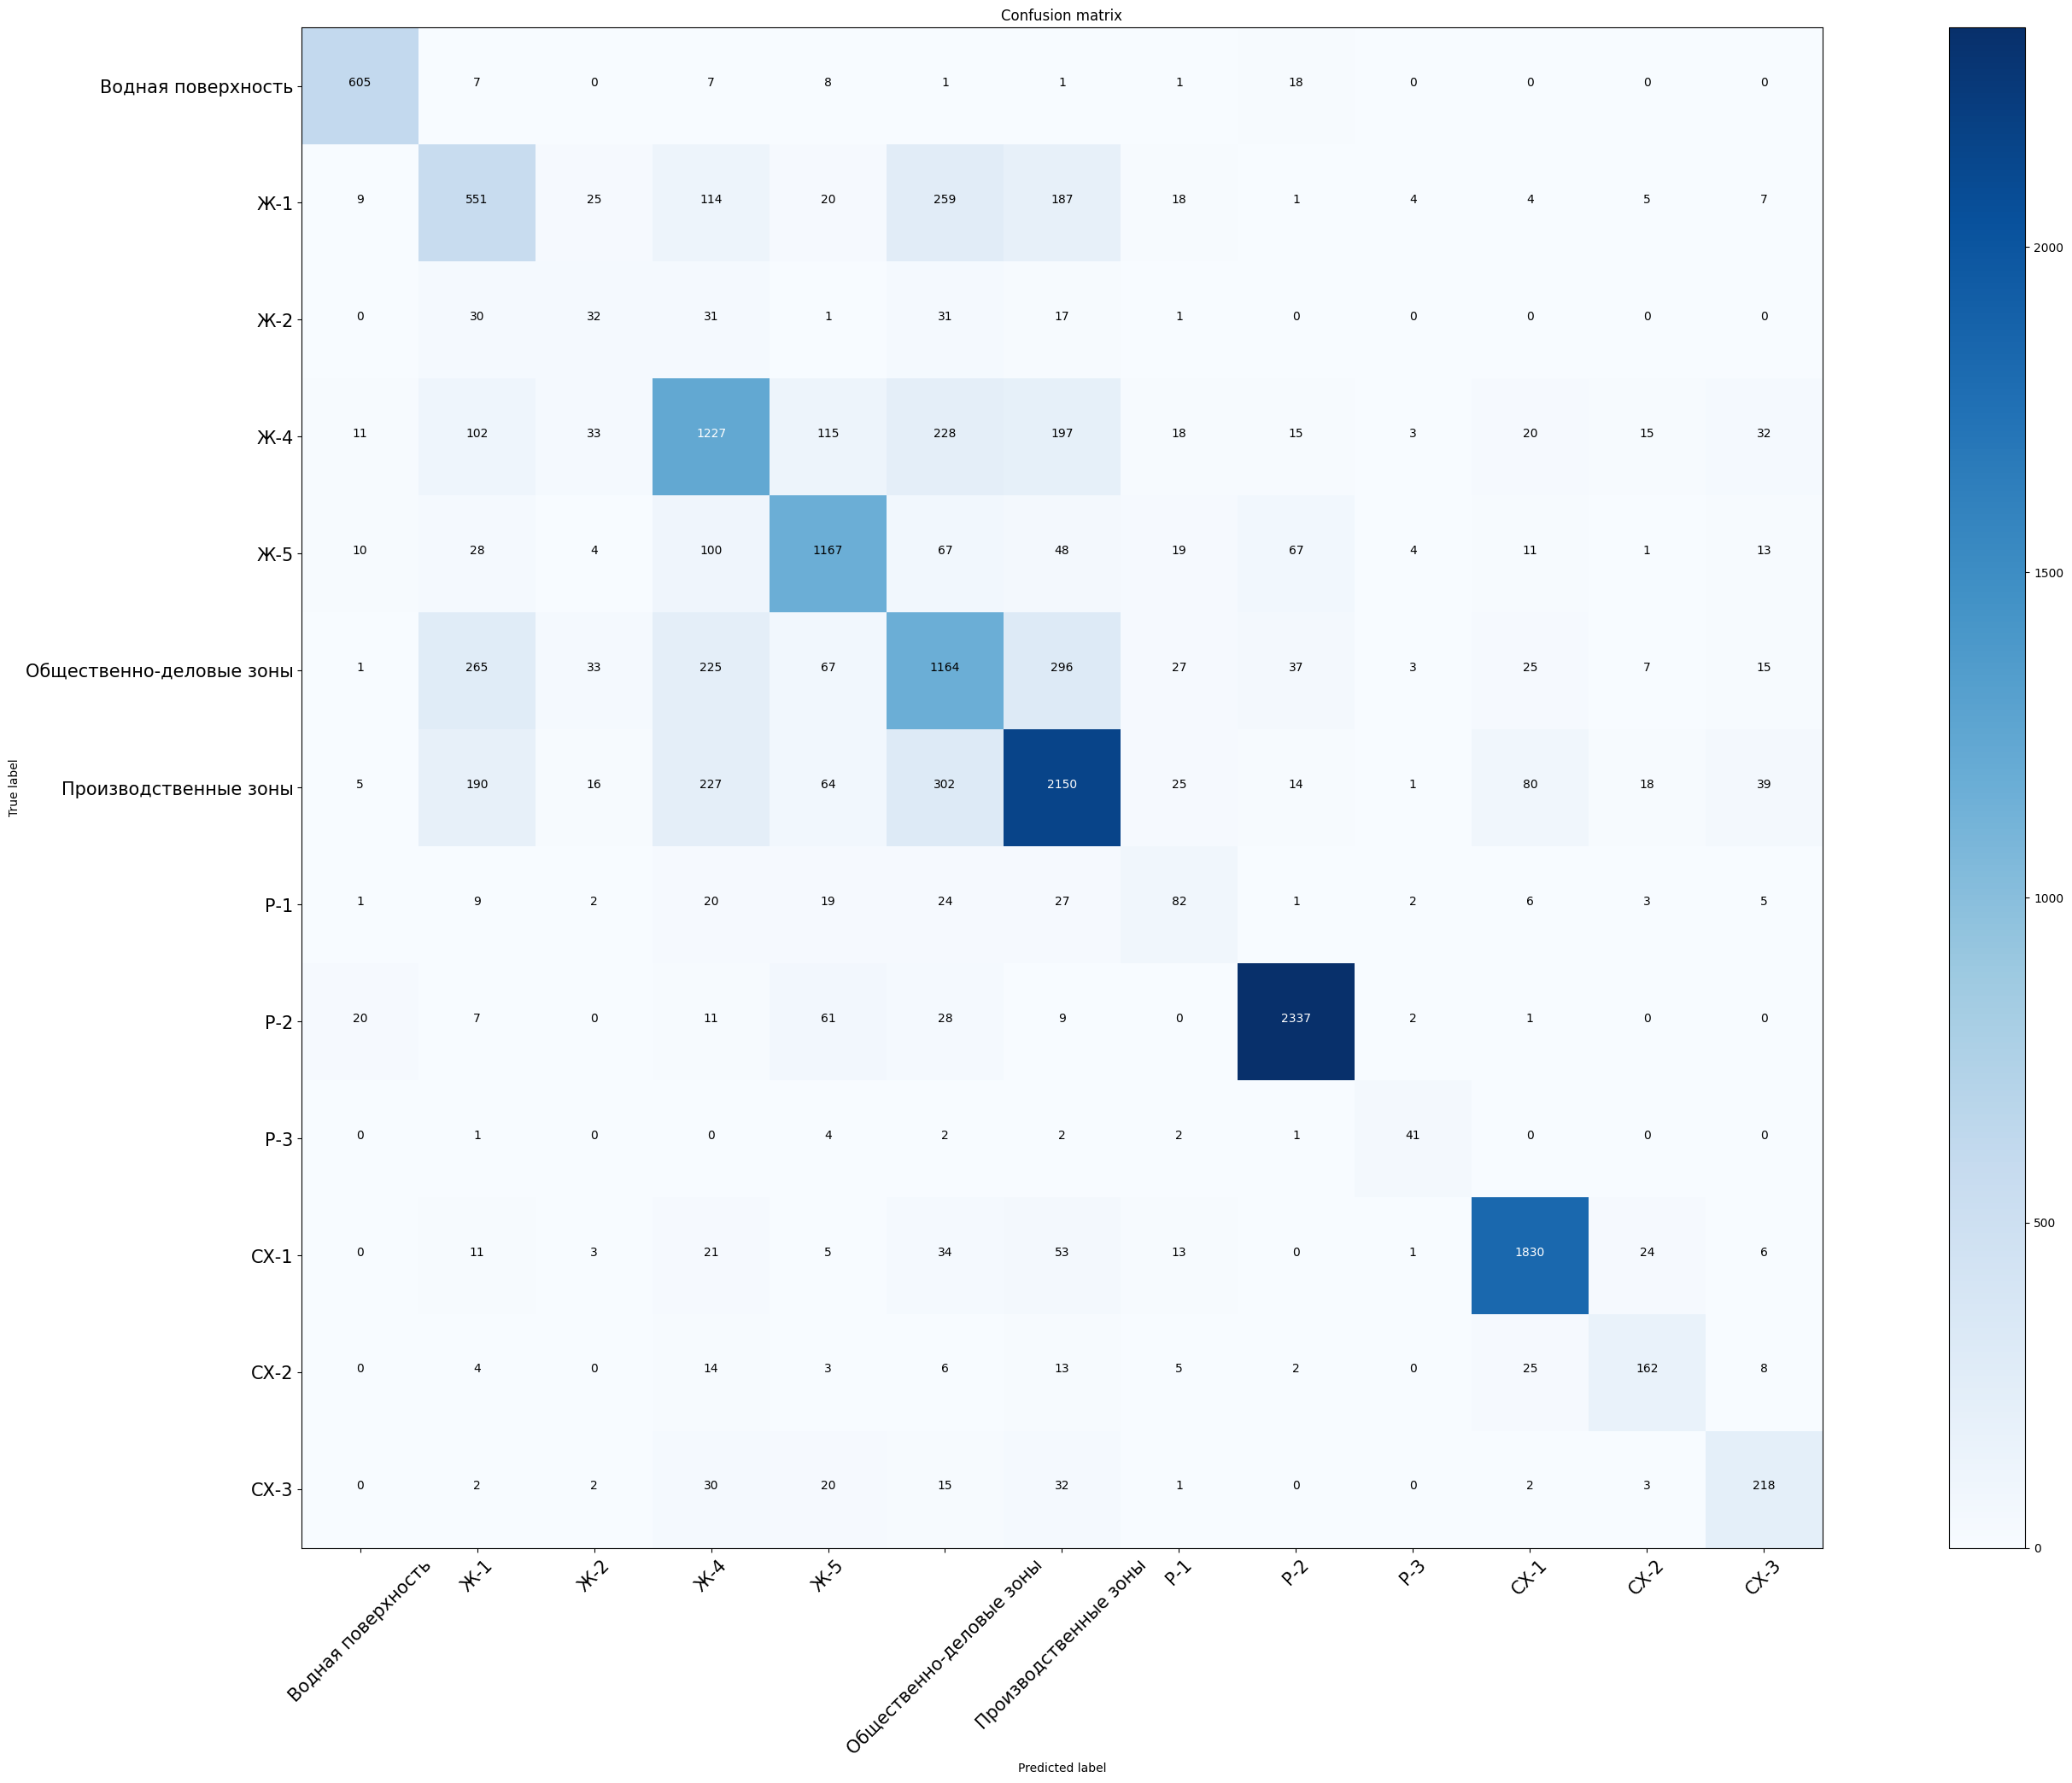

In [14]:
plt.figure(figsize=(30, 20))
cnf_matrix = confusion_matrix(y_test, model_tree.predict(X_test))
plot_confusion_matrix(cnf_matrix, classes=zones,
                      title='Confusion matrix')
plt.show()

Случайный лес

In [15]:
from sklearn.ensemble import RandomForestClassifier
# Обучаем модель случайного леса
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_train)
dict_classification = classification_report(y_train, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

,precision,recall,f1-score,support
Водная поверхность,0.999614,1.000000,0.999807,2592.000000
Ж-1,1.000000,1.000000,1.000000,4818.000000
Ж-2,1.000000,1.000000,1.000000,574.000000
Ж-4,1.000000,0.999876,0.999938,8061.000000
Ж-5,1.000000,1.000000,1.000000,6155.000000
Общественно-деловые зоны,1.000000,1.000000,1.000000,8659.000000
Производственные зоны,1.000000,1.000000,1.000000,12521.000000
Р-1,1.000000,1.000000,1.000000,805.000000
Р-2,1.000000,1.000000,1.000000,9905.000000
Р-3,1.000000,1.000000,1.000000,212.000000


In [16]:
from sklearn.ensemble import RandomForestClassifier
# Обучаем модель случайного леса
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
dict_classification = classification_report(y_test, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

,precision,recall,f1-score,support
Водная поверхность,0.921168,0.973765,0.946737,648.000000
Ж-1,0.570297,0.478405,0.520325,1204.000000
Ж-2,0.933333,0.097902,0.177215,143.000000
Ж-4,0.624742,0.751488,0.682279,2016.000000
Ж-5,0.818685,0.768681,0.792895,1539.000000
Общественно-деловые зоны,0.616631,0.527483,0.568584,2165.000000
Производственные зоны,0.723342,0.790802,0.755569,3131.000000
Р-1,0.917808,0.333333,0.489051,201.000000
Р-2,0.937886,0.981826,0.959353,2476.000000
Р-3,0.900000,0.679245,0.774194,53.000000


Как видно из таблиц выше наша модель переобучается(высокая точность, практически всегда 1 на тренировочных данных и низкая на тестовых), попробуем несколько подходов для исправления ситуации

Попробуем подобрать гиперпараметры

In [17]:
grid_space={'max_depth':[3, 5, 10, None],
              'n_estimators':[10, 100, 200, 250],
              'max_features':[1, 3, 5, 7],
              'min_samples_leaf':[1, 2, 3, 4, 5],
              'min_samples_split':[2, 3, 4, 5]
           }

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.1, 
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# best_clf = RandomizedSearchCV(estimator=RandomForestClassifier(), param_distributions=grid_space, n_iter=150, cv=3, verbose=2, 
#                               random_state=42, n_jobs=-1)
best_clf = RandomForestClassifier(n_estimators=100, min_samples_split=3, min_samples_leaf=2, max_features=7, max_depth=None)
model_grid = best_clf.fit(X_train, y_train)
y_pred = model_grid.predict(X_train)
dict_classification = classification_report(y_train, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()
# print('Best hyperparameters are: ' + str(model_grid.best_params_))
# print('Best score is: ' + str(model_grid.best_score_))

,precision,recall,f1-score,support
Водная поверхность,0.984778,0.997430,0.991064,2335.000000
Ж-1,0.997673,0.994204,0.995935,4313.000000
Ж-2,1.000000,0.939689,0.968907,514.000000
Ж-4,0.991488,0.995726,0.993603,7253.000000
Ж-5,0.990402,0.987719,0.989059,5537.000000
Общественно-деловые зоны,0.994065,0.985923,0.989977,7814.000000
Производственные зоны,0.990379,0.995122,0.992745,11275.000000
Р-1,0.997050,0.923497,0.958865,732.000000
Р-2,0.991684,0.997213,0.994441,8969.000000
Р-3,0.994565,0.973404,0.983871,188.000000


In [19]:
# best_clf = RandomForestClassifier(n_estimators=100, min_samples_split=3, min_samples_leaf=2, max_features=7, max_depth=None)
# model_grid = best_clf.fit(X_train, y_train)
y_best_pred = model_grid.predict(X_test)
dict_classification = classification_report(y_test, y_best_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()
# результаты на валидационных данных

,precision,recall,f1-score,support
Водная поверхность,0.918248,0.970679,0.943736,648.000000
Ж-1,0.604905,0.553156,0.577874,1204.000000
Ж-2,0.764706,0.090909,0.162500,143.000000
Ж-4,0.682609,0.778770,0.727525,2016.000000
Ж-5,0.837966,0.803119,0.820173,1539.000000
Общественно-деловые зоны,0.655864,0.588915,0.620589,2165.000000
Производственные зоны,0.767527,0.807729,0.787115,3131.000000
Р-1,0.813187,0.368159,0.506849,201.000000
Р-2,0.940426,0.981826,0.960680,2476.000000
Р-3,0.916667,0.830189,0.871287,53.000000


Confusion matrix, without normalization
[[ 629    2    0    2    3    0    3    0    9    0    0    0    0]
 [   6  666    1  122   14  224  159    0    1    0    3    1    7]
 [   0   28   13   31    4   51   14    0    0    0    0    2    0]
 [  15   59    1 1570   74  112  132    1   10    0   18    8   16]
 [  10   15    1  124 1236   21   42    2   66    2   16    1    3]
 [   1  212    0  233   44 1275  301    6   49    1   30    5    8]
 [   3  112    1  144   46  210 2529    4   12    0   46    2   22]
 [   1    7    0   27   16   29   25   74    4    1   12    0    5]
 [  20    0    0    1   14    9    1    0 2431    0    0    0    0]
 [   0    0    0    0    1    3    2    0    1   44    2    0    0]
 [   0    0    0    8    2    4   38    3    0    0 1941    5    0]
 [   0    0    0   10    2    4   18    1    2    0   27  175    3]
 [   0    0    0   28   19    2   31    0    0    0    3    0  242]]


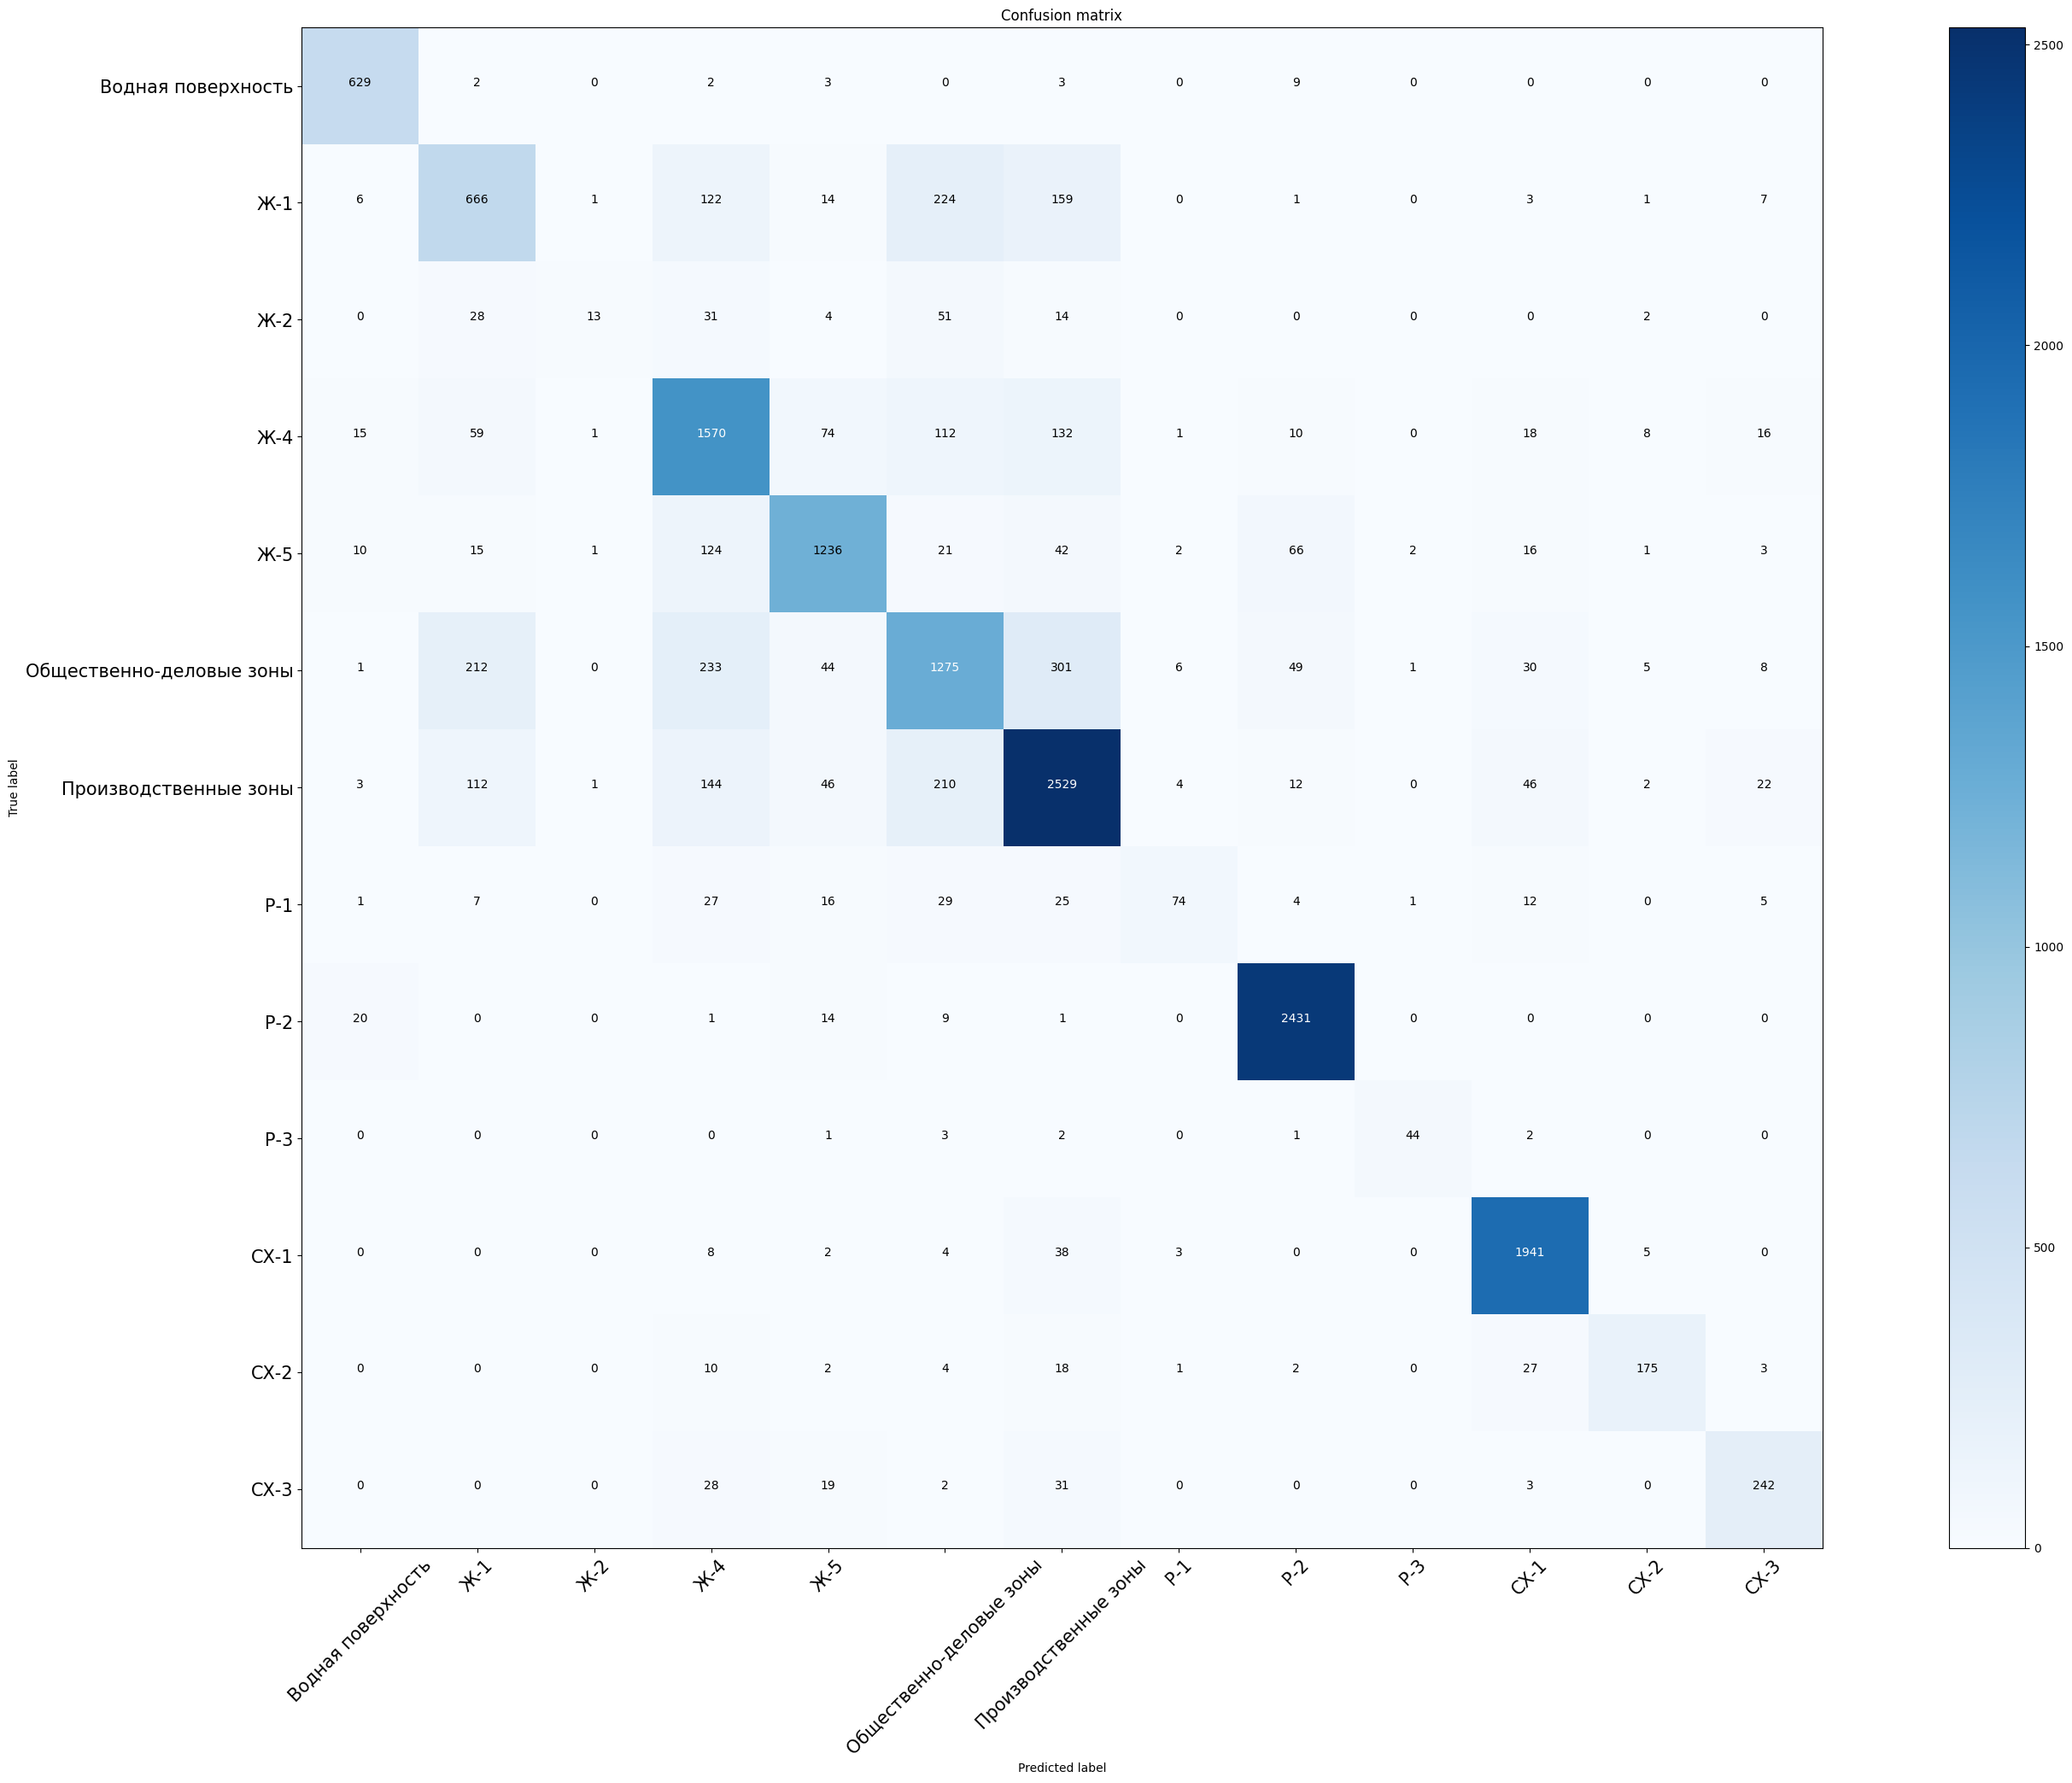

In [20]:
y_pred = model_grid.predict(X_test)
plt.figure(figsize=(30, 20))
cnf_matrix = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cnf_matrix, classes=zones,
                      title='Confusion matrix')
plt.show()

Feature Importance

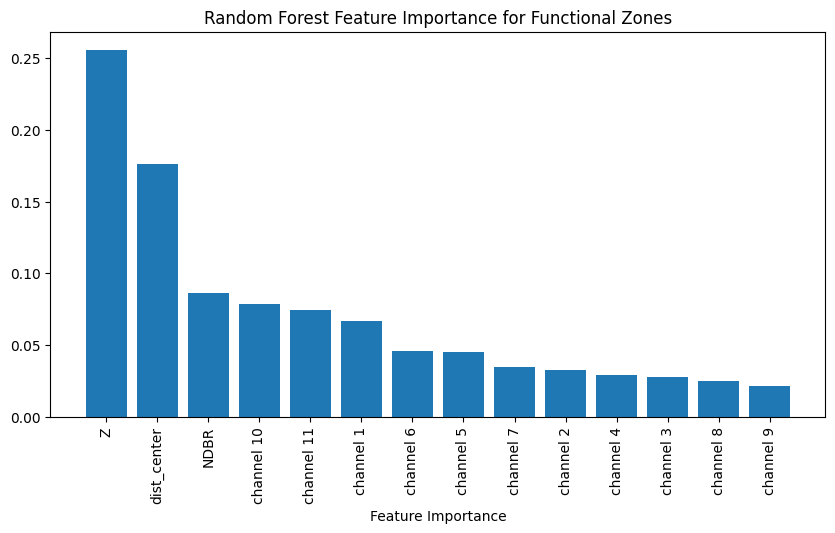

In [21]:
feature_importances = model_grid.feature_importances_
# print(feature_importances)
data_new_columns = data.drop(columns=['target']).columns
feature_names = data_new_columns

# Sort and plot
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance for Functional Zones")
plt.show()

LIME

In [22]:
! pip install ipython


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
! pip install lime


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
data = data.drop('target', axis=1)

In [25]:
len(data.columns)

14

In [26]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt


explainer = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names=data.columns, class_names=zones, mode='classification')
it = 0
for i in range(len(X_test)):
  if y_test[i] == 10 and y_best_pred[i] == 10: # проверяем, насколько правильно интерпретируется признак СХ-1 10 это СХ-1
    explanation = explainer.explain_instance(
        data_row=X_test[i],
        predict_fn=model_grid.predict_proba,
        num_features=14)
    explanation.show_in_notebook(show_table=True)
    # explanation.as_list()
    # print(explanation.as_list())
    # построить здесь хороший график
    # fig = explanation.as_pyplot_figure()

    it += 1
    if it == 30: break



ImportError: cannot import name 'display' from 'IPython.core.display' (c:\Users\79370\PycharmProjects\second_course_work_georaphy\.venv\Lib\site-packages\IPython\core\display.py)

SHAP

In [ ]:
! pip install shap


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
! pip install ipywidgets

  Obtaining dependency information for ipywidgets from https://files.pythonhosted.org/packages/56/6d/0d9848617b9f753b87f214f1c682592f7ca42de085f564352f10f0843026/ipywidgets-8.1.8-py3-none-any.whl.metadata
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import shap

# explainer = shap.TreeExplainer(model_grid)
# shap_values = explainer.shap_values(X)
# shap.summary_plot(shap_values, X)

In [ ]:
# dependency_plot
# shap.dependence_plot("Z", shap_values, X_test)

Проведём K-Fold Stratified кросс-валидацию, так как по здесь:https://education.yandex.ru/handbook/ml/article/kross-validaciya и здесь: https://blog.skillfactory.ru/chto-takoe-kross-validatsiya/ утверждается, что она лучше подходит для задач, где классы несбалансированы

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
 
skf = StratifiedKFold(n_splits=20, shuffle=True)
best_clf = RandomForestClassifier(n_estimators=100, min_samples_split=3, min_samples_leaf=2, max_features=7, max_depth=None) # наш алгоритм классификации
cross_validation_accuracy = -1
cross_validation_model = model_grid
for train_index, test_index in skf.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
    y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]
    model_grid = best_clf.fit(X_train_fold, y_train_fold)
    # cur_score = model_grid.score(X_test_cur, y_test_cur)
    y_pred_fold = model_grid.predict(X_test_fold)
    cur_score = sum(y_pred_fold == y_test_fold) / len(y_pred_fold)
    if cur_score > cross_validation_accuracy:
        cross_validation_accuracy = cur_score
        # y_test_cross_validation = y_test
        cross_validation_model = model_grid
        print(cross_validation_accuracy)
        # X_test_cross_validation = X_test_cur_

0.8761183757742601
0.8768066070199587
0.8774948382656572
0.8830006882312457


KeyboardInterrupt: 

Проверим, какая точность получилась после кросс валидации

In [ ]:
y_cross_validation_pred = cross_validation_model.predict(X_val)
dict_classification = classification_report(y_val, y_cross_validation_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

IndexError: list index out of range

Подборём гиперпараметры при помощи байесовской оптимизации и библиотеки Optuna

In [ ]:
! pip install optuna

  Obtaining dependency information for optuna from https://files.pythonhosted.org/packages/75/d1/6c8a4fbb38a9e3565f5c36b871262a85ecab3da48120af036b1e4937a15c/optuna-4.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for alembic>=1.5.0 from https://files.pythonhosted.org/packages/83/36/cd9cb6101e81e39076b2fbe303bfa3c85ca34e55142b0324fcbf22c5c6e2/alembic-1.18.1-py3-none-any.whl.metadata
  Obtaining dependency information for colorlog from https://files.pythonhosted.org/packages/6d/c1/e419ef3723a074172b68aaa89c9f3de486ed4c2399e2dbd8113a4fdcaf9e/colorlog-6.10.1-py3-none-any.whl.metadata
  Obtaining dependency information for sqlalchemy>=1.4.2 from https://files.pythonhosted.org/packages/f7/4e/510db49dd89fc3a6e994bee51848c94c48c4a00dc905e8d0133c251f41a7/sqlalchemy-2.0.45-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/d0/30/dc54f88dd4a2b5dc8a0279bdd7270e735851848b762aeb1c1184ed1f6b14/tqdm-4.67.1-py3-


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import optuna
from sklearn.metrics import accuracy_score

c:\Users\79370\PycharmProjects\second_course_work_georaphy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def objective(trial): 
    # Загружаем нужные нам данные 
    X_train_optuna, X_test_optuna, y_train_optuna, y_test_optuna = train_test_split(X, y, test_size=0.2)  

    # Выбираем оптимизируемые параметры 
    n_estimators = trial.suggest_categorical('n_estimators', [10, 100, 200, 250]) 
    max_depth = trial.suggest_categorical('max_depth', [3, 5, 10, None])
    max_features = trial.suggest_categorical('max_features', [1, 3, 5, 7])
    min_samples_leaf  = trial.suggest_categorical('min_samples_leaf', [1, 2, 3, 4, 5])
    min_samples_split = trial.suggest_categorical('min_samples_split', [2, 3, 4, 5])

    # Обучаем модель 
    model = RandomForestClassifier(n_estimators=n_estimators, 
                                max_depth=max_depth, max_features=max_features,
                                min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split)
    model.fit(X_train_optuna, y_train_optuna)  

    y_pred_optuna = model.predict(X_test_optuna)
    accuracy = accuracy_score(y_test_optuna, y_pred_optuna)
    return accuracy

In [ ]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=150)

best_params = study.best_params
best_accuracy = study.best_value
print('Best params:', best_params)
print('Best accuracy:', best_accuracy)
# [I 2026-01-19 19:14:24,924] Trial 15 finished with value: 0.8881937561942518 and parameters: {'n_estimators': 100, 'max_depth': None, 'max_features': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}. Best is trial 15 with value: 0.8881937561942518

[I 2026-01-19 18:31:33,658] A new study created in memory with name: no-name-1293c1da-c319-4d57-b6c3-de8e1965adb1
[I 2026-01-19 18:31:42,309] Trial 0 finished with value: 0.5965064420218038 and parameters: {'n_estimators': 100, 'max_depth': 5, 'max_features': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}. Best is trial 0 with value: 0.5965064420218038.
[I 2026-01-19 18:32:28,485] Trial 1 finished with value: 0.7460356788899901 and parameters: {'n_estimators': 100, 'max_depth': 10, 'max_features': 7, 'min_samples_leaf': 3, 'min_samples_split': 4}. Best is trial 1 with value: 0.7460356788899901.
[I 2026-01-19 18:32:30,697] Trial 2 finished with value: 0.49200941526263625 and parameters: {'n_estimators': 10, 'max_depth': 3, 'max_features': 7, 'min_samples_leaf': 4, 'min_samples_split': 3}. Best is trial 1 with value: 0.7460356788899901.
[I 2026-01-19 18:33:34,709] Trial 3 finished with value: 0.8824331020812686 and parameters: {'n_estimators': 100, 'max_depth': None, 'max_features': 7

KeyboardInterrupt: 

Классификация при помощи XGBoost

In [ ]:
! pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/3a/d8/4d4ae25452577f2dfabc66b60e712e7c01f9fe6c389fa88c546c2f427c4d/xgboost-3.1.3-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 682.7 kB/s eta 0:01:46
   ---------------------------------------- 0.0/72.0 MB 653.6 kB/s eta 0:01:51
   ---------------------------------------- 0.1/72.0 MB 1.0 MB/s eta 0:01:10
   ---------------------------------------- 0.3/72.0 MB 2.0 MB/s eta 0:00:37
   ---------------------------------------- 0.5/72.0 MB 2.6 MB/s eta 0:00:28
   ---------------------------------------- 0.9/72.0 MB 3.8 MB/s eta 0:00:19
    --------------------------------------- 1.3/72.0 MB 4.8 MB/s eta 0:00:15
    --------------------------------------- 1.7/72.0 MB 5.3 MB/s eta 0:00:14
    --------------------------------------- 1.7/72.0 MB 5.3 MB/s eta 0:00:14
    ------------------------


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_classifier = xgb.XGBClassifier(random_state=42)

xgb_classifier.fit(X_train, y_train)

y_pred = xgb_classifier.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")


dict_classification = classification_report(y_val, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

Validation Accuracy: 0.7894


,precision,recall,f1-score,support
Водная поверхность,0.902527,0.972763,0.936330,257.000000
Ж-1,0.604119,0.522772,0.560510,505.000000
Ж-2,0.636364,0.116667,0.197183,60.000000
Ж-4,0.666302,0.753713,0.707317,808.000000
Ж-5,0.811728,0.851133,0.830964,618.000000
Общественно-деловые зоны,0.631158,0.560947,0.593985,845.000000
Производственные зоны,0.768697,0.800161,0.784113,1246.000000
Р-1,0.800000,0.438356,0.566372,73.000000
Р-2,0.956476,0.962607,0.959531,936.000000
Р-3,0.937500,0.625000,0.750000,24.000000


Попробуем подобрать гиперпараметры для XGBoost

In [ ]:
# param_grid = {
#     'n_estimators': [100, 200, 300, 500],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 6, 9],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.7, 0.85, 1.0],
#     'colsample_bytree': [0.7, 0.85, 1.0],
#     'reg_alpha': [0, 0.01, 0.1, 1, 10, 100],
#     'reg_lambda': [0.5, 0.7, 1, 1.3]
# }

# xgb_model = xgb.XGBClassifier(random_state=42)

# grid_search = RandomizedSearchCV(xgb_model, param_grid, cv=10, scoring="accuracy", n_iter=100, n_jobs=-1, verbose=2, random_state=42)
# grid_search.fit(X_train, y_train)

# best_xgb = grid_search.best_estimator_

# # Best parameters from tuning
# print("Best Parameters:", grid_search.best_params_)
# print("Best Accuracy:", grid_search.best_score_)
# # Fitting 10 folds for each of 100 candidates, totalling 1000 fits
# # Best Parameters: {'subsample': 1.0, 'reg_lambda': 1.3, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
# # Best Accuracy: 0.8909239885913255

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


KeyboardInterrupt: 

Проверка качества модели на тренировочной выборке

In [ ]:
best_xgb = xgb.XGBClassifier(random_state=42, subsample=1.0, reg_lambda=0, reg_alpha=10, n_estimators=300, min_child_weight=1, max_depth=9, learning_rate=0.2, colsample_bytree=1.0)
best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_train)
print("\Train Classification\n")
dict_classification = classification_report(y_train, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()
# reg_alpha=10 - нет переобучения L1 регуляризация
# reg_lambda особо не влияет

<>:4: SyntaxWarning: invalid escape sequence '\T'
<>:4: SyntaxWarning: invalid escape sequence '\T'
C:\Users\79370\AppData\Local\Temp\ipykernel_19892\2300260817.py:4: SyntaxWarning: invalid escape sequence '\T'
  print("\Train Classification\n")


\Train Classification



,precision,recall,f1-score,support
Водная поверхность,0.946743,0.989722,0.967755,2335.000000
Ж-1,0.898490,0.896824,0.897656,4313.000000
Ж-2,0.916667,0.449416,0.603133,514.000000
Ж-4,0.895493,0.945126,0.919640,7253.000000
Ж-5,0.947465,0.934802,0.941091,5537.000000
Общественно-деловые зоны,0.907020,0.876376,0.891435,7814.000000
Производственные зоны,0.932533,0.951308,0.941827,11275.000000
Р-1,0.925852,0.631148,0.750609,732.000000
Р-2,0.979367,0.989631,0.984472,8969.000000
Р-3,0.968944,0.829787,0.893983,188.000000


Проверка качества модели на тестовой выборке

In [53]:
y_pred = best_xgb.predict(X_test)
print("\Test Classification\n")
dict_classification = classification_report(y_test, y_pred, target_names=zones.astype(str).tolist(), output_dict=True)
pd.DataFrame(dict_classification).transpose()

<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\T'
C:\Users\79370\AppData\Local\Temp\ipykernel_19892\1927330974.py:2: SyntaxWarning: invalid escape sequence '\T'
  print("\Test Classification\n")


\Test Classification



,precision,recall,f1-score,support
Водная поверхность,0.913994,0.967593,0.940030,648.000000
Ж-1,0.609075,0.579734,0.594043,1204.000000
Ж-2,0.545455,0.125874,0.204545,143.000000
Ж-4,0.708162,0.770337,0.737943,2016.000000
Ж-5,0.840026,0.829110,0.834532,1539.000000
Общественно-деловые зоны,0.647295,0.596767,0.621005,2165.000000
Производственные зоны,0.785824,0.817950,0.801565,3131.000000
Р-1,0.738739,0.407960,0.525641,201.000000
Р-2,0.948093,0.973748,0.960749,2476.000000
Р-3,0.906977,0.735849,0.812500,53.000000


Confusion matrix, without normalization
[[ 627    3    0    1    3    0    2    0   12    0    0    0    0]
 [   6  698    3   93   10  246  137    1    0    1    1    1    7]
 [   0   34   18   37    3   35   14    0    0    0    0    1    1]
 [   8   61    4 1553   83  122  131    1   11    0   15    9   18]
 [  10   13    1   98 1276   25   41    4   51    1   15    0    4]
 [   1  227    5  199   47 1292  285    9   39    1   36   11   13]
 [   2   98    2  148   34  201 2561    6   12    1   42    7   17]
 [   1    9    0   17   14   34   19   82    4    0   10    4    7]
 [  31    0    0    5   11   18    0    0 2411    0    0    0    0]
 [   0    0    0    0    4    5    3    0    0   39    1    0    1]
 [   0    2    0   12    2    7   28    6    0    0 1938    5    1]
 [   0    0    0    8    6    6   11    2    3    0   15  186    5]
 [   0    1    0   22   26    5   27    0    0    0    3    2  239]]


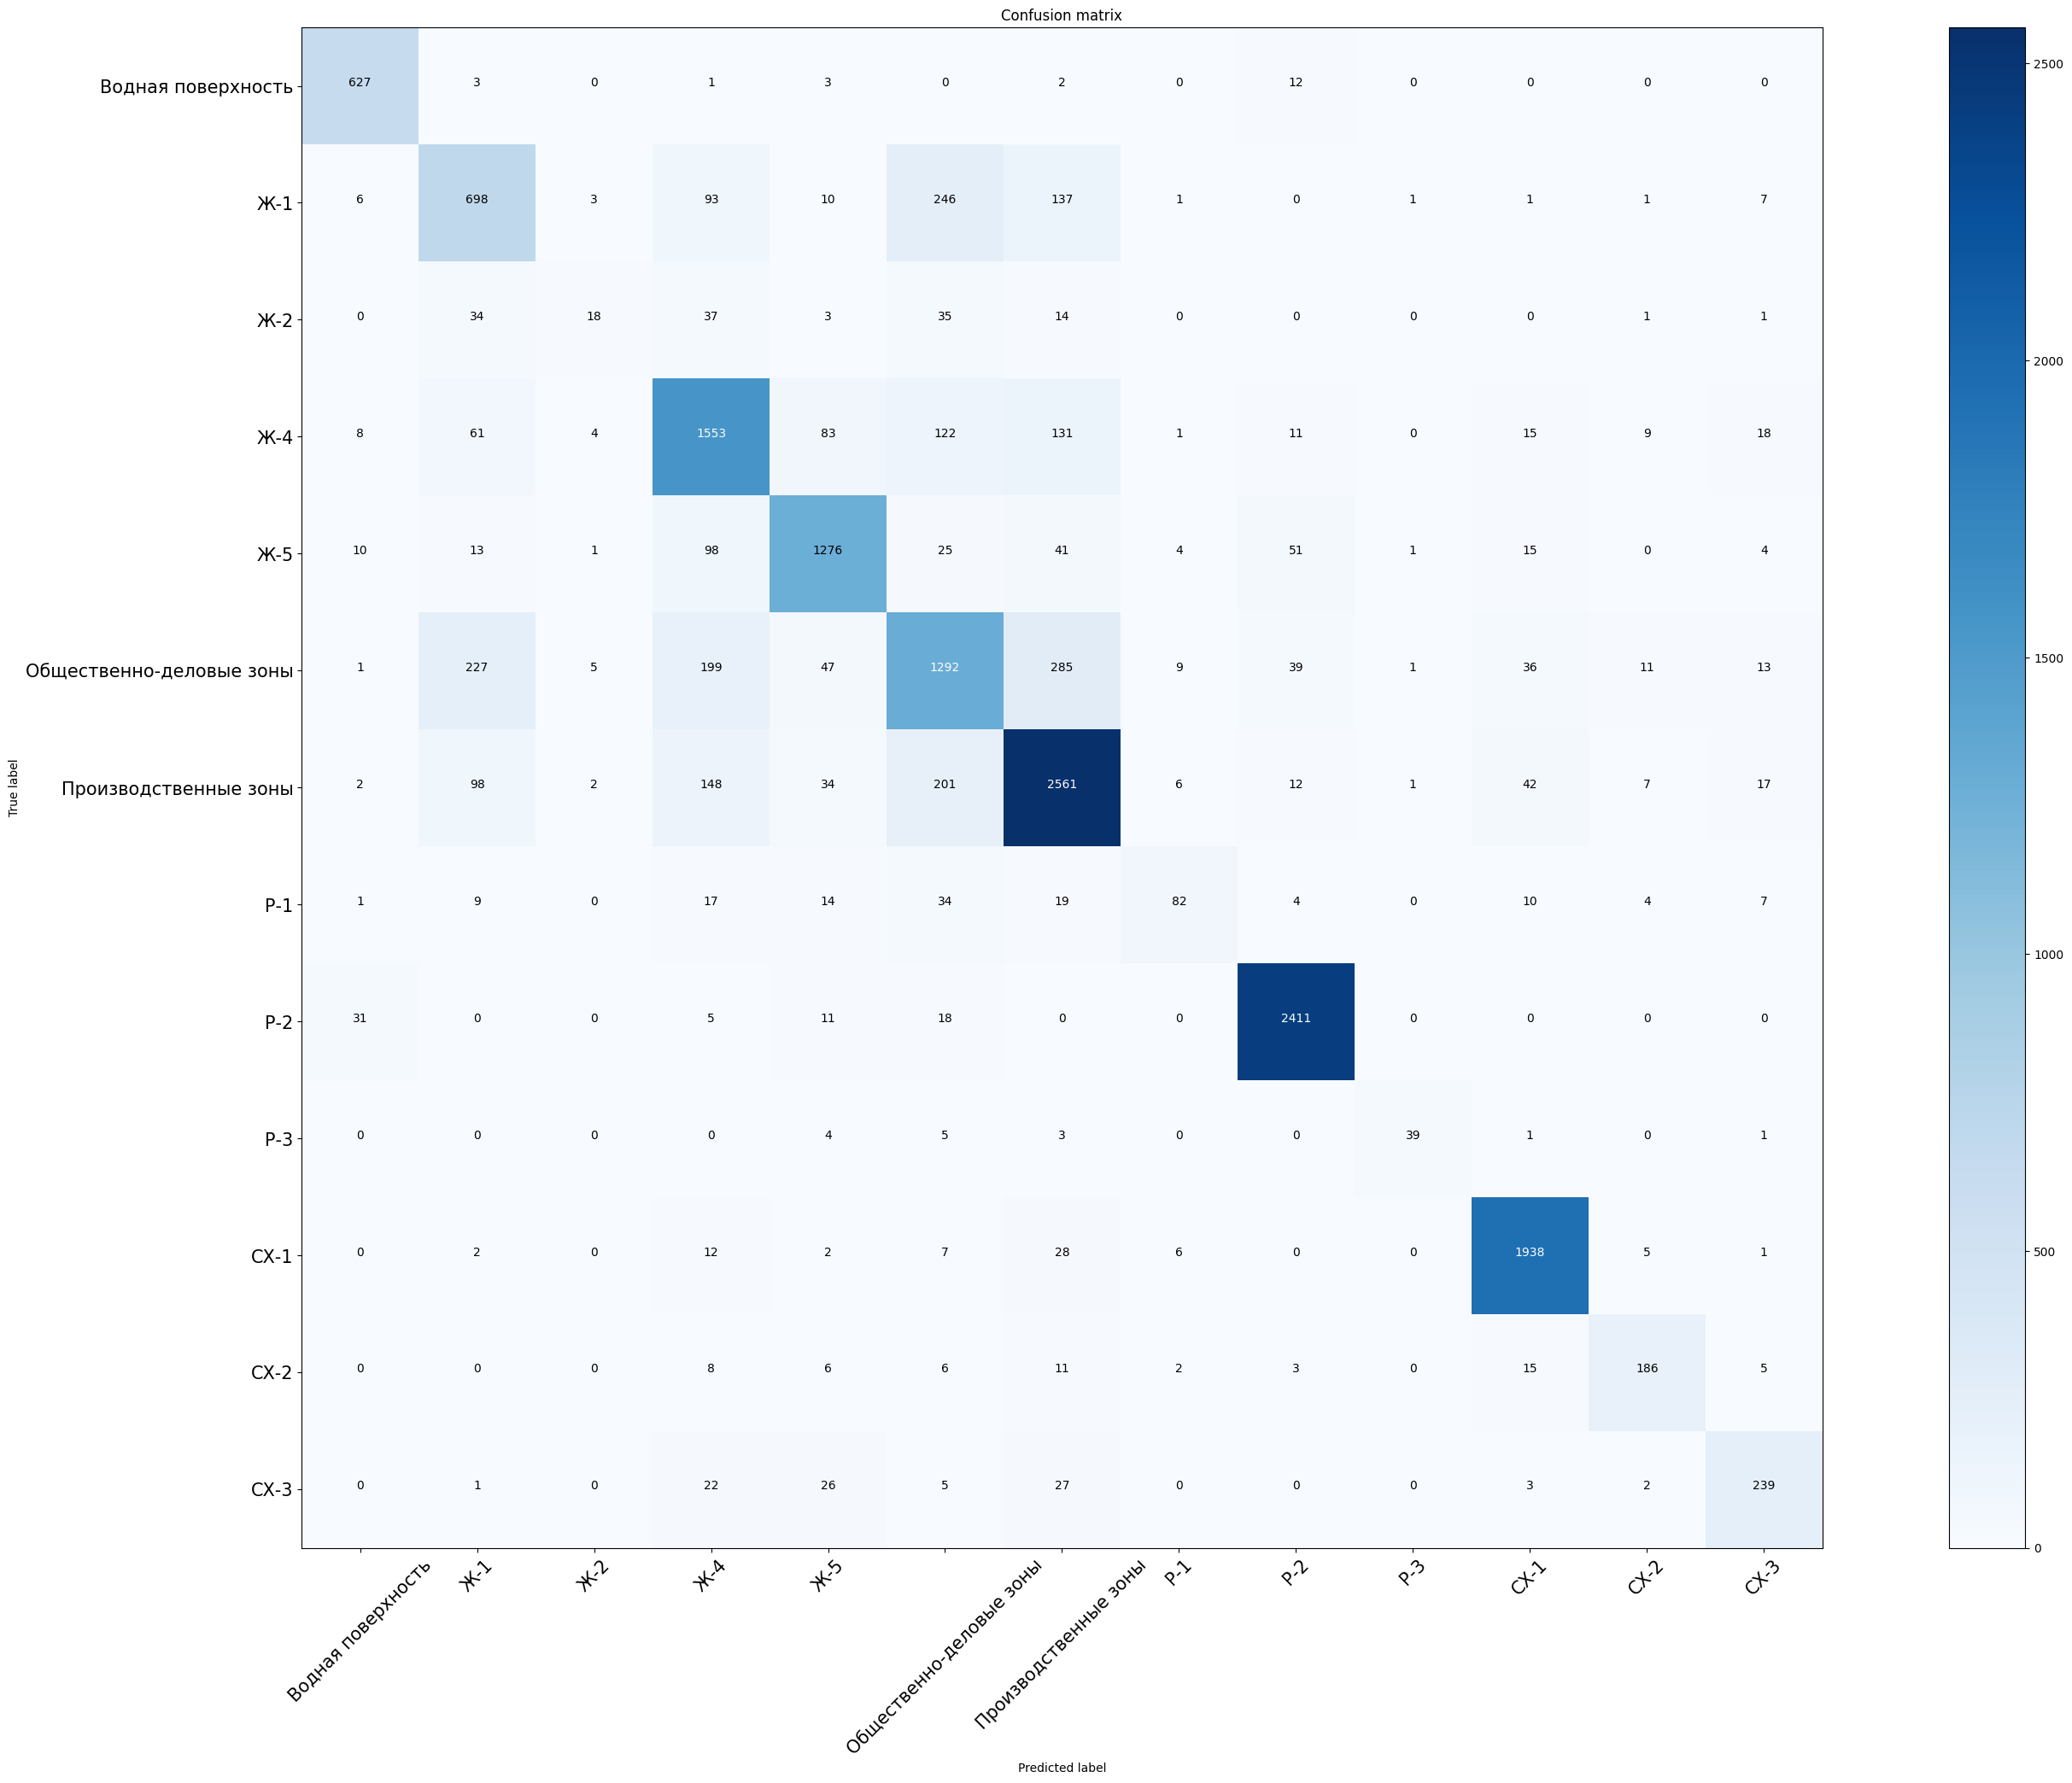

In [54]:
plt.figure(figsize=(30, 20))
cnf_matrix = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cnf_matrix, classes=zones,
                      title='Confusion matrix')
plt.show()

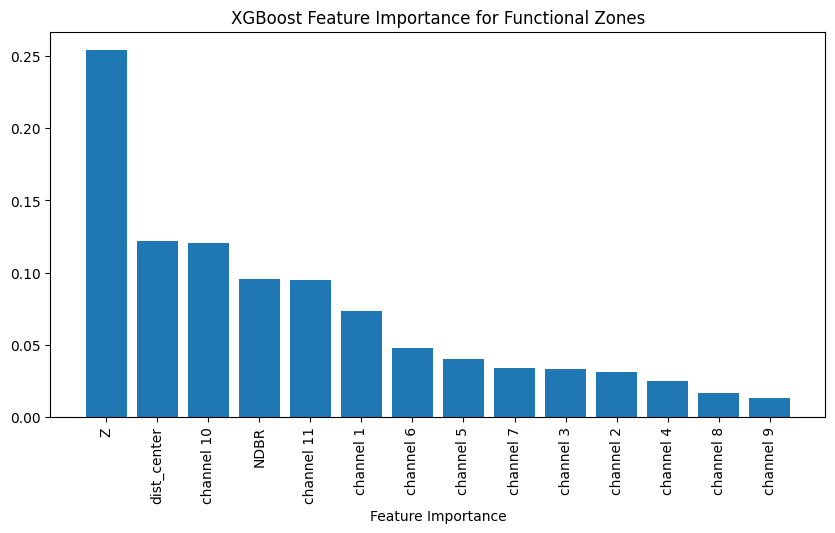

In [52]:
feature_importances = best_xgb.feature_importances_
# print(feature_importances)
# data_new_columns = data.drop(columns=['target']).columns
feature_names = data_new_columns

# Sort and plot
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align="center")
plt.xticks(range(len(feature_importances)), np.array(feature_names)[sorted_indices], rotation=90)
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance for Functional Zones")
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

Классификация при помощи LightGBM

In [ ]:
! pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.5 MB 653.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.5 MB 1.1 MB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.5 MB 1.7 MB/s eta 0:00:01
   ---------- ----------------------------- 0.4/1.5 MB 2.0 MB/s eta 0:00:01
   ----------------- ---------------------- 0.6/1.5 MB 2.9 MB/s eta 0:00:01
   ------------------------ --------------- 0.9/1.5 MB 3.3 MB/s eta 0:00:01
   --------------------------------- ------ 1.2/1.5 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.5 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 1


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from numpy import mean, std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from lightgbm import LGBMClassifier


model = LGBMClassifier()
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
# report performance
print(n_scores.mean())

[0.7524777  0.76994549 0.77056492 0.77353816 0.77849356 0.78766105
 0.76251239 0.71837443 0.76223516 0.78119192 0.78047572 0.77973241
 0.77960852 0.77998018 0.76350347 0.76288404 0.72472745 0.78230703
 0.77735101 0.7424111  0.78332507 0.75755699 0.79038652 0.77713082
 0.77514866 0.78208622 0.77254708 0.78428943 0.76074836 0.7752447 ]


In [ ]:
# import lightgbm as lgb

# skf = StratifiedKFold(n_splits=20, shuffle=True)
# for train_index, test_index in skf.split(X_train, y_train):
#     X_train_fold, X_test_fold = X_train[train_index], X_train[test_index]
#     y_train_fold, y_test_fold = y_train[train_index], y_train[test_index]
    
#     train_data = lgb.Dataset(X_tr, label = y_tr, reference=data_all)

#     params = {'metric':['auc', 'binary_logloss'], 'objective': 'binary'}

#     clf = lgb.train(params, train_data, num_boost_round=cv_res['cvbooster'].best_iteration)
#     auc_l.append(roc_auc_score(y_val, clf.predict(X_val)))